# 🚢 타이타닉 데이터로 배우는 EDA (탐색적 데이터 분석)

> **비어플 신입세션 · 실습 + 과제 노트북**

## 이 노트북으로 무엇을 하나요?
이 노트북 한 권으로 다음 세 가지를 연습합니다.

1. **Jupyter Notebook(.ipynb) 기초** — 셀 다루기, 단축키, 코드/마크다운 구분
2. **데이터 첫 탐색** — 데이터를 불러오고, 크기·자료형·결측치를 확인하는 습관
3. **변수별 EDA** — 변수 하나하나를 그래프와 요약통계로 뜯어보기

## 이 노트북을 푸는 방법
- 📖 **설명 셀**: 읽고 넘어가세요. 개념과 함수 사용법이 정리되어 있습니다.
- ▶️ **예시 코드 셀**: `Shift + Enter`로 직접 실행해 보세요. 결과를 눈으로 확인하는 게 핵심입니다.
- ✏️ **직접 해보기 (빈 셀)**: 위 예시를 따라 여러분이 직접 코드를 채우는 칸입니다. 정답은 정해져 있지 않아요 — 여러 함수를 시도해 보세요.
- 🎯 **과제**: 노트북 맨 아래에 제출용 과제가 있습니다.

## ⚠️ 시작하기 전에 딱 하나!
아래 데이터를 불러오는 셀의 **파일 경로**를 여러분 컴퓨터에 맞게 바꿔야 합니다.
가장 쉬운 방법은 **이 노트북(.ipynb)과 `Titanic-Dataset.csv`를 같은 폴더에 두고**, 경로를 파일 이름만 남기는 것입니다:

```python
data = pd.read_csv("Titanic-Dataset.csv")
```

---

# 파일 및 라이브러리 불러오기

# ⌨️ Jupyter Notebook 기초 & 단축키

Jupyter의 셀은 두 종류입니다.
- **코드 셀(Code)**: 파이썬 코드를 실행합니다.
- **마크다운 셀(Markdown)**: 지금 읽고 있는 것처럼 글/제목/목록을 씁니다.

셀 왼쪽이 파란색이면 **명령 모드**(셀 자체를 조작), 초록색이면 **편집 모드**(셀 안 내용 수정)입니다. `Esc`를 누르면 명령 모드로 빠져나옵니다.

## 셀 추가 및 삭제 (명령 모드에서)
1. `Esc` → `b` : **아래(below)**에 셀 추가
2. `Esc` → `a` : **위(above)**에 셀 추가
3. `Esc` → `d` `d` (d 두 번) : 셀 삭제

## 마크다운 ↔ 코드 셀 변환 (명령 모드에서)
4. `Esc` → `m` : **마크다운(markdown)** 셀로 변경
5. `Esc` → `y` : **코드(code)** 셀로 변경

## 셀 실행
6. `Shift + Enter` : 실행 후 **아래 셀로 이동**
7. `Ctrl + Enter` : 실행 후 **제자리 유지**

> 💡 **연습:** 이 셀 아래에 `Esc → b`로 새 셀을 만들고, `Esc → m`으로 마크다운으로 바꾼 뒤 자기 이름을 써서 실행(`Shift + Enter`)해 보세요. 다 했으면 `Esc → d d`로 지워도 됩니다.

## 📦 라이브러리 불러오기

분석에 쓸 도구(라이브러리)를 먼저 불러옵니다. 각 줄의 주석에 무슨 역할인지 적혀 있으니 읽어보세요.
- **pandas**: 표(데이터프레임) 다루기의 핵심
- **numpy**: 수치 계산
- **matplotlib / seaborn**: 그래프 그리기
- **koreanize_matplotlib**: 그래프에서 한글이 깨지지 않게 해주는 도구

> 이 셀은 노트북을 열 때마다 **가장 먼저 한 번** 실행해야 합니다.

In [3]:
import numpy as np                  # 수치 계산/벡터·행렬 연산(NumPy)
import pandas as pd                 # 데이터프레임 생성·가공·요약(Pandas)

import matplotlib.pyplot as plt     # 기본 시각화 라이브러리(Matplotlib)
plt.rc('font', family='Malgun Gothic')  # 한글 폰트 설정(그래프에서 한글 깨짐 방지)

!pip install koreanize-matplotlib   
import koreanize_matplotlib         # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정

from IPython.display import display # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용

import seaborn as sns               # 통계 시각화(분포/관계/범주형 비교) 라이브러리(Seaborn)

## 📂 데이터 불러오기

`pd.read_csv("파일경로")`로 CSV 파일을 데이터프레임으로 읽어옵니다.

**⚠️ 아래 셀의 경로를 반드시 여러분 환경에 맞게 바꾸세요.**
csv 파일을 이 노트북과 같은 폴더에 두었다면 아래처럼 파일명만 남기면 됩니다:

```python
data = pd.read_csv("Titanic-Dataset.csv")
```

In [4]:
data = pd.read_csv("Titanic-Dataset.csv")

불러온 데이터를 통째로 확인해 봅니다. 변수 이름만 쳐서 실행하면 표가 예쁘게 출력됩니다.

In [5]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 🔎 1단계 · 데이터 첫인상 파악하기

분석을 시작하면 **가장 먼저** 데이터의 전체 모습을 훑어봅니다. "어떤 변수가, 몇 개, 어떤 형태로 있고, 빠진 값은 없는지"를 확인하는 단계예요.

| 함수 | 하는 일 |
|------|---------|
| `data.head(n)` | 위에서 n행 보기 (기본 5행) |
| `data.tail(n)` | 아래에서 n행 보기 (기본 5행) |
| `data.info()` | 컬럼별 자료형(dtype), 결측치 개수, 메모리 |
| `data.describe()` | 숫자형 변수의 요약통계량 |
| `data.shape` | (행 개수, 열 개수) |
| `data.columns` | 변수(열) 이름 목록 |
| `data.dtypes` | 변수별 자료형 |
| `data.nunique()` | 변수별 고유값 개수 → 범주형인지 추측 |
| `data.isnull().sum()` | 변수별 결측치 개수 |

> 아래 셀들을 하나씩 실행하면서 **출력이 무엇을 말하는지** 옆의 주석과 함께 읽어보세요.

### 🚢 타이타닉 데이터 변수 설명
| 변수 | 의미 |
|------|------|
| `Survived` | 생존 여부 (0=사망, 1=생존) — **우리가 가장 궁금한 값** |
| `Pclass` | 객실 등급 (1=1등석, 2=2등석, 3=3등석) |
| `Name` | 이름 |
| `Sex` | 성별 |
| `Age` | 나이 |
| `SibSp` | 함께 탄 형제자매/배우자 수 |
| `Parch` | 함께 탄 부모/자녀 수 |
| `Ticket` | 티켓 번호 |
| `Fare` | 운임(요금) |
| `Cabin` | 객실 번호 |
| `Embarked` | 탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton) |

In [6]:
data.head() #앞에 5개 행 추출

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
data.tail() #뒤에 5개 행 추출

# 데이터셋에서 대게 마지막 행들은 결측치로 냅둘 가능성이 존재함.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
data.info() #결측치, 변수 타입, 데이터 차원 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
data.describe() #기술통계량 확인

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
data.shape # 행,열 개수

(891, 12)

In [11]:
data.columns # 변수들 보기

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
data.dtypes # 변수 type

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
data.nunique() # 고유값 개수 확인 -> 범주형일지 유추

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

### 결측치(빠진 값) 확인
`isnull()`은 각 칸이 비었는지 True/False로 알려줍니다. 여기에 `.sum()`을 붙이면 **변수별로 빈 칸이 몇 개인지** 셀 수 있어요.
타이타닉 데이터에서는 특히 **Age(나이)**와 **Cabin(객실번호)**에 결측치가 많습니다 — 나중에 어떻게 처리할지 고민할 지점입니다.

In [14]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
data.isnull().sum().sort_values() #결측치 개수 오름차순 정렬

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64

<Axes: >

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

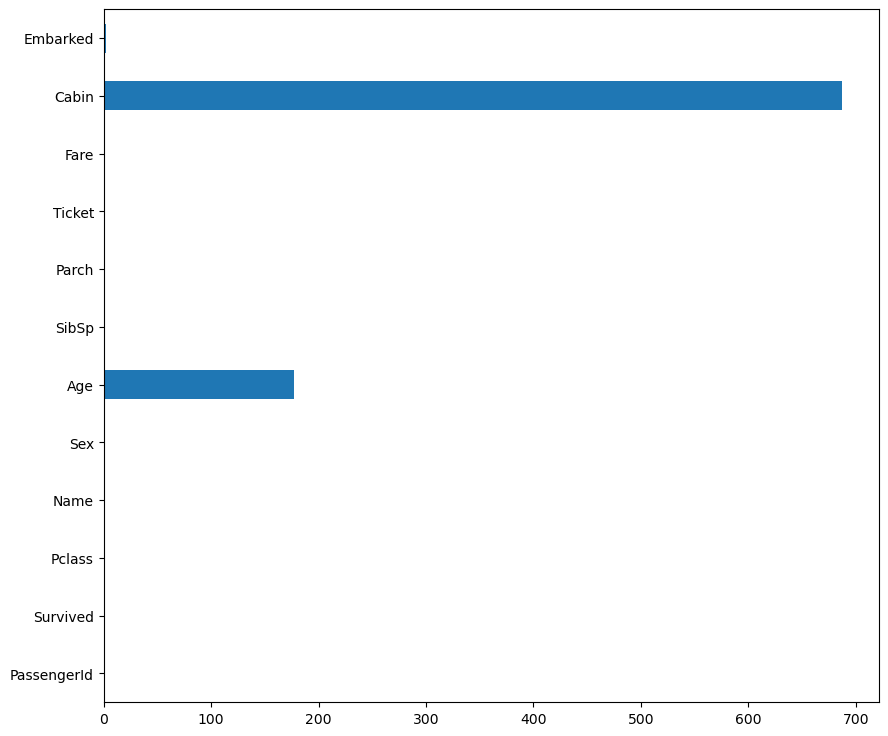

In [16]:
## 결측치 시각화 (only 가독성있게 결측치를 확인하기 위해서)
data.isnull().sum().plot.barh(figsize=(10, 9))

In [17]:
# 모든 변수가 다 NA인 행 axis = 0 일 땐, 열
data.isnull().all(axis=1)

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [18]:
# 모든 변수가 다 NA인 행 개수
data.isna().all(axis=1).sum()

np.int64(0)

# 📊 2단계 · 변수별 EDA

이제 변수를 **하나씩** 자세히 들여다봅니다. 변수의 성격(범주형이냐 연속형이냐)에 따라 보는 방법이 달라요.

## 변수 종류에 따른 접근
- **범주형 변수** (예: Survived, Sex, Pclass, Embarked) → 개수/비율을 세고 막대·원 그래프로
- **연속형 변수** (예: Age, Fare) → 요약통계량 + 히스토그램·박스플롯으로 분포 확인

## 자주 쓰는 함수
| 함수 | 하는 일 |
|------|---------|
| `.value_counts()` | 고유값들의 개수 |
| `.value_counts(normalize=True)` | 고유값들의 **비율** |
| `.plot(kind="bar")` | 막대그래프 |
| `plt.pie(...)` | 원(파이) 그래프 |
| `.describe()` | 요약통계량 |
| `sns.histplot(...)` | 히스토그램(분포) |
| `sns.boxplot(...)` | 박스플롯(중앙값·이상치 확인) |

> **학습 흐름:** 앞부분(Survived, Age)은 **예시가 채워져 있습니다.** 뒷부분 변수(Pclass, Sex, SibSp, Parch, Ticket, Fare, Cabin, Embarked)는 **여러분이 직접** 위 예시를 따라 빈 셀을 채우는 연습입니다. ✏️

## passenger id
- 제거

In [19]:
data1 = data.drop(columns=["PassengerId"]).copy()

In [20]:
# 변수명 확인
data1.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## ✅ Survived (생존 여부) — \[예시\]

- `1` = 생존, `0` = 사망
- 숫자로 저장돼 있지만 **의미상 범주형**입니다.
- 이 변수가 우리 분석의 **핵심 타깃**이에요. 아래 코드를 실행하며 "개수 → 비율 → 그래프" 순서로 보는 흐름을 익혀두세요. 다른 범주형 변수도 똑같은 방식으로 봅니다.

In [21]:
data1["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [22]:
data1["Survived"].value_counts(normalize = True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: title={'center': 'Survived'}, xlabel='Survived'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

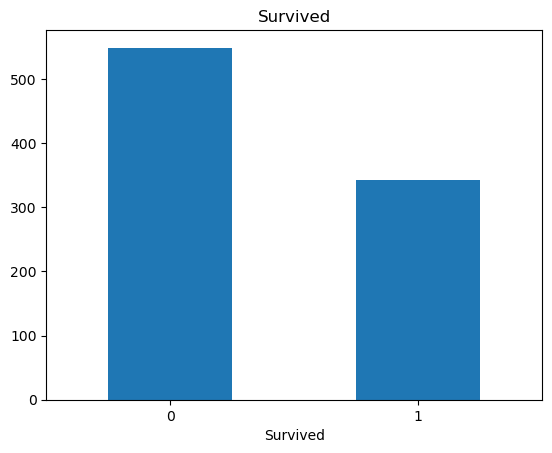

In [23]:
data1["Survived"].value_counts().plot(kind="bar",rot=0, title="Survived")

Survived
0    549
1    342
Name: count, dtype: int64


Text(0.5, 1.0, 'Survival Rate (Pie)')

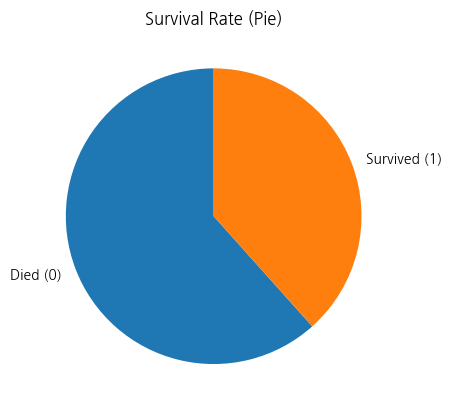

In [24]:
counts = data1["Survived"].value_counts().sort_index()  # 범주별 count한 통계량 먼저 만들기
print(counts)
plt.pie(
    counts.values,
    labels=["Died (0)", "Survived (1)"],
    startangle=90
)
plt.title("Survival Rate (Pie)")

## ✏️ Pclass (객실 등급) — 직접 해보기

- `1` = 1등석, `2` = 2등석, `3` = 3등석 → **범주형**
- 위 **Survived 예시**와 똑같은 방식으로 아래 빈 셀을 채워보세요.

**해볼 것**
1. `data1["Pclass"].value_counts()` — 등급별 인원수
2. `data1["Pclass"].value_counts(normalize=True)` — 비율
3. 막대그래프로 시각화
4. (생각해보기) 어떤 등급에 사람이 가장 많나요?

In [25]:
data1['Pclass'].value_counts(normalize = True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [26]:
data1['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

## ✏️ Sex (성별) — 직접 해보기

- `male`, `female` → **범주형**

**해볼 것**
1. 성별 인원수와 비율 확인 (`value_counts`)
2. 막대그래프 또는 원그래프로 시각화

In [25]:
data1['Sex'].value_counts(normalize = True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [24]:
data1['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: title={'center': 'Sex'}, xlabel='Sex'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

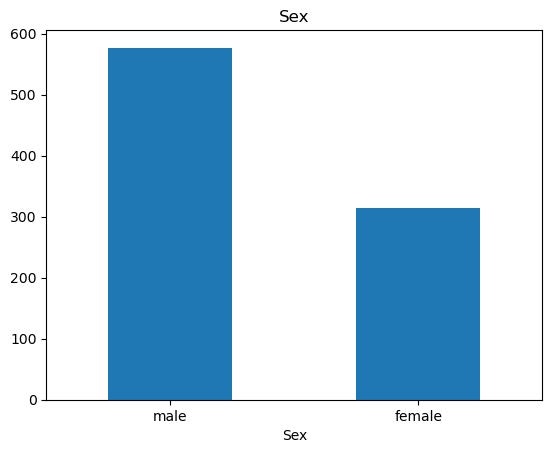

In [26]:
data1['Sex'].value_counts().plot(kind = 'bar', rot = 0, title = 'Sex')

## 📈 Age (나이) — \[예시\] · 연속형 변수 다루기

Age는 **연속형** 변수입니다. 범주형과 달리 개수를 세는 대신 **분포**를 봅니다.
- `.describe()` : 평균·표준편차·사분위수 등 요약통계량
- **히스토그램**(`histplot`) : 값이 어디에 몰려 있는지
- **박스플롯**(`boxplot`) : 중앙값과 이상치(outlier)

> 💡 Age에는 결측치가 있어서 그래프를 그리기 전에 `.dropna()`로 빈 값을 빼주는 점에 주목하세요.

In [23]:
data1["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

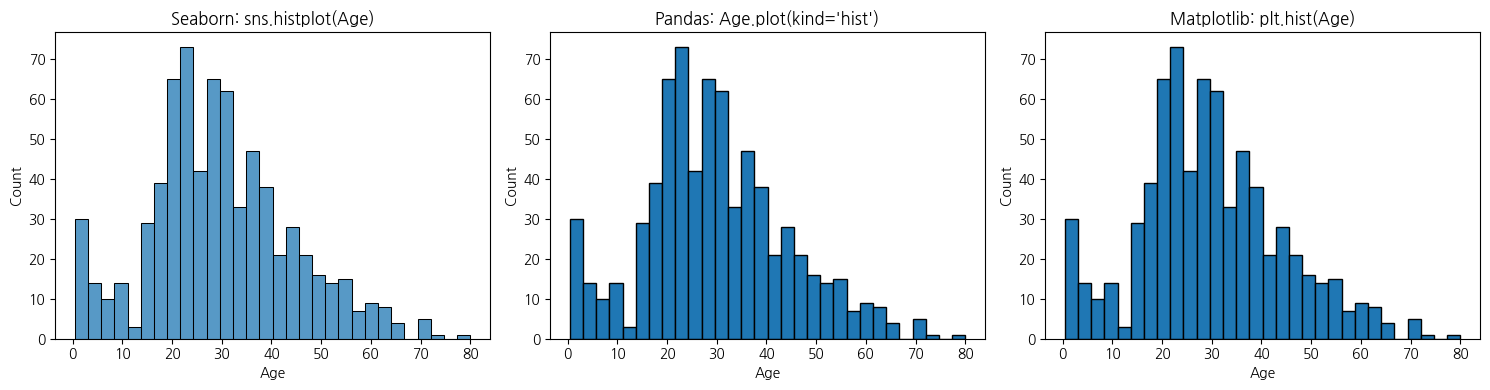

In [24]:
age = data1["Age"].dropna()
bins = 30

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) seaborn
sns.histplot(age, bins=bins, ax=axes[0])
axes[0].set_title("Seaborn: sns.histplot(Age)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# 2) pandas .plot
age.plot(kind="hist", bins=bins, edgecolor="black", ax=axes[1])
axes[1].set_title("Pandas: Age.plot(kind='hist')")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

# 3) matplotlib
axes[2].hist(age, bins=bins, edgecolor="black")
axes[2].set_title("Matplotlib: plt.hist(Age)")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

<Axes: ylabel='Age'>

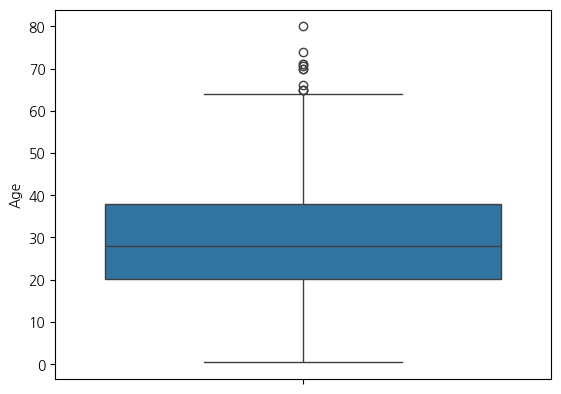

In [25]:
sns.boxplot(data1['Age'])

> ✏️ **직접 해보기:** Age 히스토그램의 `bins` 값을 10, 50 등으로 바꿔가며 모양이 어떻게 달라지는지 관찰해 보세요.

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

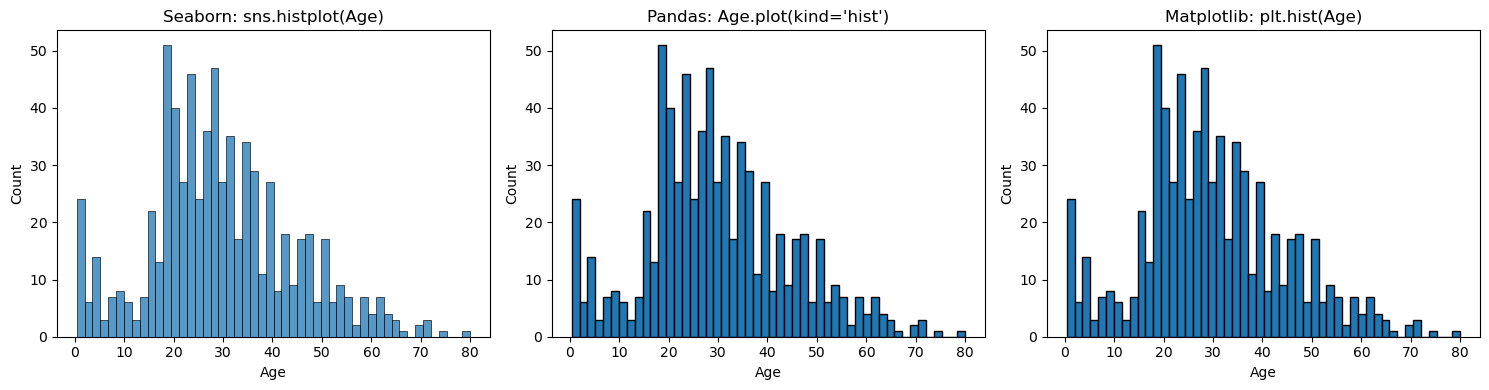

In [30]:
age = data1["Age"].dropna()
bins = 50

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) seaborn
sns.histplot(age, bins=bins, ax=axes[0])
axes[0].set_title("Seaborn: sns.histplot(Age)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# 2) pandas .plot
age.plot(kind="hist", bins=bins, edgecolor="black", ax=axes[1])
axes[1].set_title("Pandas: Age.plot(kind='hist')")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

# 3) matplotlib
axes[2].hist(age, bins=bins, edgecolor="black")
axes[2].set_title("Matplotlib: plt.hist(Age)")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## ✏️ SibSp — 같이 탑승한 형제자매/배우자 수 · 직접 해보기

값이 0~8인 **정수형**이지만, 종류가 몇 개 안 되므로 **범주형처럼** 다뤄도 됩니다.

**해볼 것**
1. `value_counts()`로 값 분포 확인 (대부분 0명입니다)
2. 막대그래프로 시각화
3. `describe()`로 평균도 확인해보기

In [32]:
data1['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [33]:
data1['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

<Axes: xlabel='SibSp'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

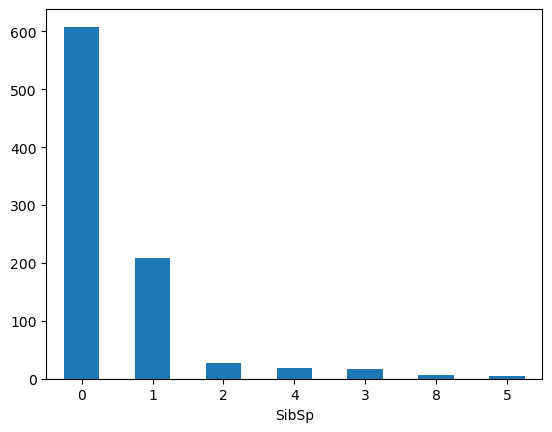

In [34]:
data1['SibSp'].value_counts().plot(kind = 'bar', rot = 0)

## ✏️ Parch — 같이 탑승한 부모/자녀 수 · 직접 해보기

SibSp와 성격이 비슷합니다. 같은 방식으로 분석해 보세요.

**해볼 것**
1. `value_counts()`로 분포 확인
2. 그래프로 시각화
3. (생각해보기) SibSp와 Parch를 합치면 무엇을 알 수 있을까요? → 노트북 뒤 '파생변수'에서 다룹니다.

In [35]:
data1['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

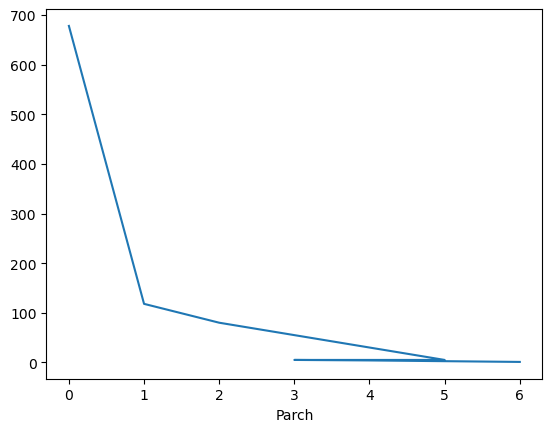

In [36]:
data1['Parch'].value_counts().plot()

# 1-3 가족 구성원의 수를 알 수 있습니다.
family = Sibsp + Parch

## ✏️ Ticket (티켓 번호) · 직접 해보기

티켓 번호는 문자+숫자가 섞인 **식별자**에 가깝습니다.

**해볼 것 / 생각해보기**
1. `data1["Ticket"].nunique()` — 고유한 티켓이 몇 개인가요?
2. `data1["Ticket"].value_counts().head()` — 같은 티켓을 여러 명이 공유하기도 합니다. 왜 그럴까요?
3. 이 변수를 그대로 분석에 쓰기 어렵다면 이유가 뭘까요? 

In [37]:
data1['Ticket'].nunique()

681

In [41]:
data1['Ticket'].value_counts().head()


Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
Name: count, dtype: int64

In [ ]:
data1['Ticket'].value_counts().tail()

Ticket
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, dtype: int64

생존율과 관련된 데이터를 구하는 것이 주제인데, 티켓은 그저 탑승자를 식별하는 것을 위할 뿐, 생존율과는 전혀 상관이 없기 떄문이다

## ✏️ Fare (운임) · 직접 해보기 — 연속형

Fare는 Age처럼 **연속형** 변수입니다. Age 예시를 참고하세요.

**해볼 것**
1. `describe()`로 요약통계량 확인
2. 히스토그램으로 분포 확인 (한쪽으로 치우쳐(skew) 있을 거예요)
3. 박스플롯으로 이상치 확인

In [45]:
data1['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: title={'center': 'Fare'}, ylabel='Frequency'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

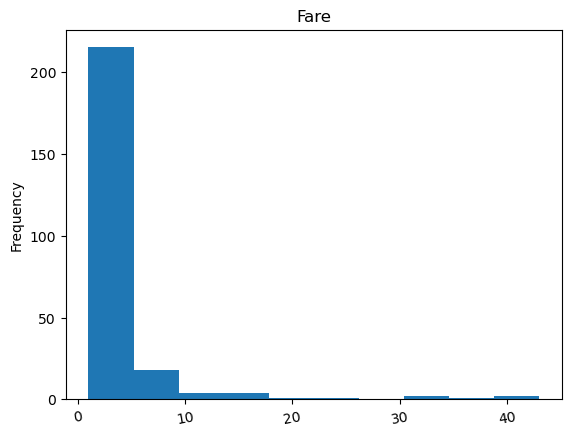

In [48]:
data1['Fare'].value_counts().plot(kind = 'hist', rot = 10, title = 'Fare')

<Axes: ylabel='Fare'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

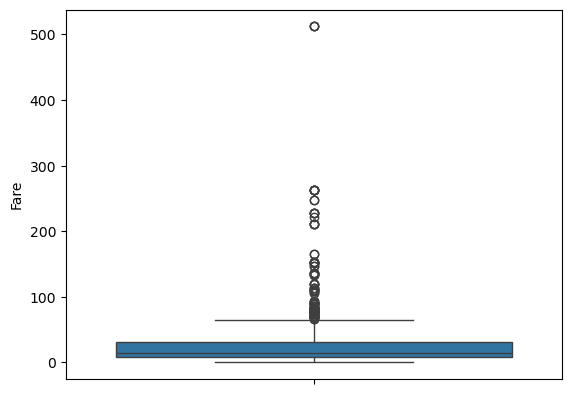

In [49]:
sns.boxplot(data1['Fare'])

## ✏️ Cabin (객실 번호) · 직접 해보기

Cabin은 **결측치가 매우 많은** 변수입니다 (약 77%가 비어 있음).

**해볼 것 / 생각해보기**
1. `data1["Cabin"].isnull().sum()` — 결측치 개수 확인
2. 결측치가 이렇게 많은 변수를 그냥 써도 될까요? 어떻게 처리하면 좋을까요? (제거 / 첫 글자만 추출 등)

In [50]:
data1["Cabin"].isnull().sum()

np.int64(687)

결측치가 어느 정도 있으면, 데이터 값들의 평균이나 중앙값 등을 구해서 사용하면 용이한데, 너무 많으면 변수를 이용하지 않는게 가장 유용한 것 같습니다

## ✏️ Embarked (탑승 항구) · 직접 해보기

- `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton → **범주형**
- 결측치가 딱 2개 있습니다.

**해볼 것**
1. `value_counts()`로 항구별 인원 확인 (S가 가장 많아요)
2. 막대/원 그래프로 시각화
3. 결측치 2개를 어떻게 채우면 좋을지 생각해보기 (힌트: 최빈값)

In [52]:
data1['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: ylabel='count'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


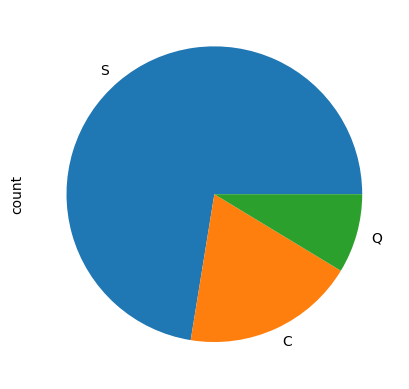

In [53]:
data1['Embarked'].value_counts().plot(kind = 'pie', rot = 0)

# 🔗 3단계 · 변수 두 개를 함께 보기

지금까지는 변수 하나씩 봤습니다. 이제 **두 변수의 관계**를 봅니다.
"어떤 변수가 생존(Survived)과 관련이 있을까?"를 찾는 것이 이 단계의 목표예요.

- **범주형 × 범주형** → 교차표(`crosstab`), 히트맵
- **범주형 × 연속형** → `groupby`로 그룹별 통계, 박스플롯

## 범주형 vs 범주형 (Survived vs Sex) — \[예시\]

`pd.crosstab(A, B)`는 두 범주형 변수의 **교차표**(각 조합별 개수)를 만듭니다.
성별에 따라 생존 인원이 어떻게 다른지 한눈에 보입니다.

> 이 예시를 참고해서, 과제에서는 **Pclass vs Survived**, **Embarked vs Survived** 등도 직접 만들어 보세요.

In [26]:
pd.crosstab(data1["Sex"], data1["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


Text(51.722222222222214, 0.5, 'Sex')

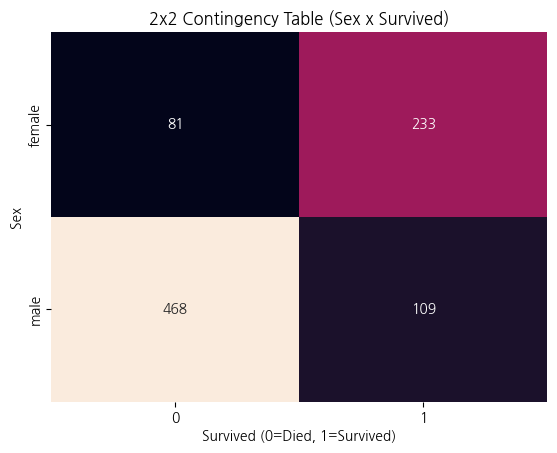

In [ ]:
ct = pd.crosstab(data["Sex"], data["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("2x2 Contingency Table (Sex x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Sex")

> ✏️ **직접 해보기:** `Pclass`와 `Survived`로 교차표와 히트맵을 만들어 보세요. 등급이 높을수록 생존율이 높을까요?

## 범주형 vs 연속형 (Pclass vs Age) — \[예시\]

`data.groupby("범주변수")["연속변수"].통계량` 형태로 **그룹별 통계**를 구합니다.
예: 등급(Pclass)별 평균 나이(Age).

박스플롯(`boxplot`)이나 막대(`barplot`)로 그룹 간 차이를 시각적으로 비교할 수 있어요.

In [28]:
#groupby를 이용해 범주별 값 보기
data.groupby("Pclass")['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

Axes(0.125,0.11;0.775x0.77)


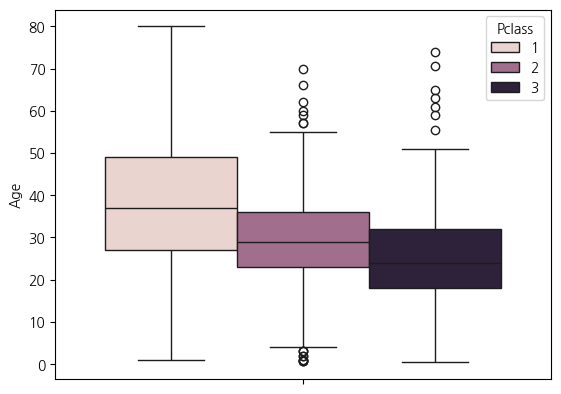

In [29]:
print(sns.boxplot(y="Age",hue="Pclass",data=data1))

<Axes: ylabel='Age'>

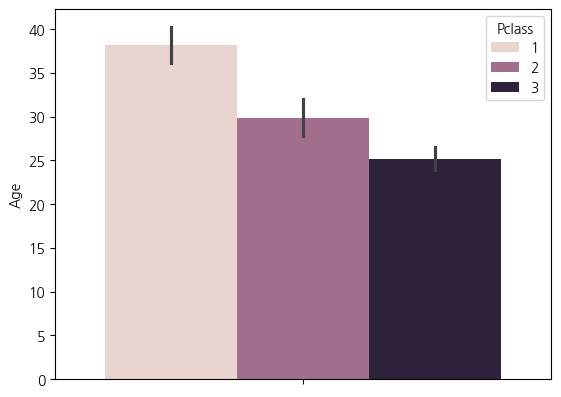

In [30]:
sns.barplot(y="Age", hue = "Pclass", data = data1)

Text(0.5, 1.0, '생존 여부에 따른 나이 ')

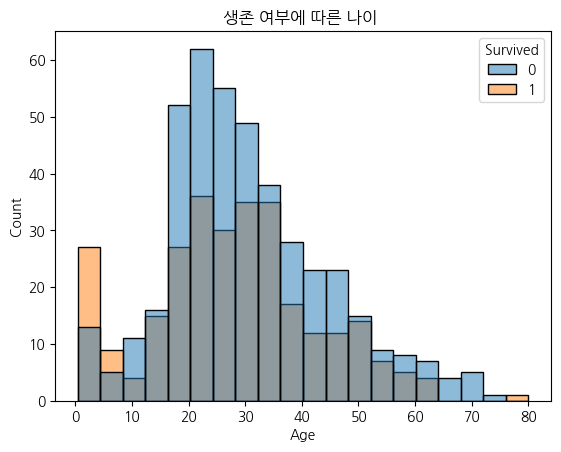

In [31]:
sns.histplot(x="Age", hue = "Survived",data = data1 )
plt.title("생존 여부에 따른 나이 ")

> ✏️ **직접 해보기:** `groupby`와 박스플롯을 이용해 **성별(Sex)에 따른 나이(Age)** 또는 **등급(Pclass)에 따른 요금(Fare)**을 비교해 보세요.

In [54]:
data.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

<Axes: ylabel='Age'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

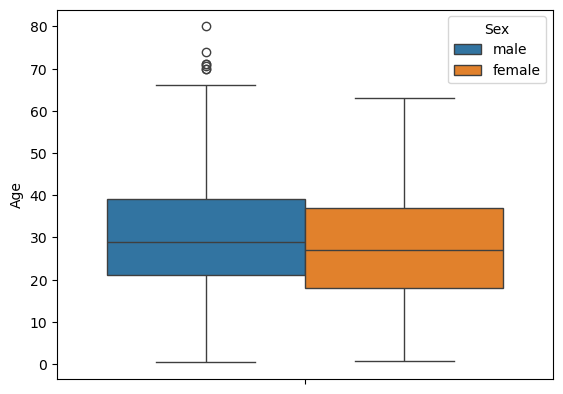

In [55]:
sns.boxplot(y = 'Age', hue = 'Sex', data = data1)

<Axes: xlabel='Pclass', ylabel='Fare'>

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

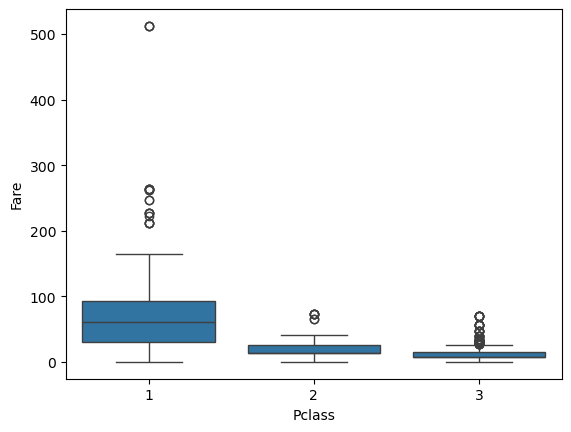

In [58]:
sns.boxplot(x = 'Pclass', y = 'Fare', data = data1)

# 🛠️ 4단계 · 파생변수 만들기

**파생변수(feature)** 란 기존 변수를 조합/변형해 **새로 만든 변수**입니다.
원래 데이터에 없던 정보를 드러내서 분석에 도움을 줄 수 있어요.

## SibSp + Parch → `family` (함께 탄 가족 수) — \[예시\]

- `SibSp`(형제자매·배우자)와 `Parch`(부모·자녀)를 더하면 **함께 탑승한 가족 총원**을 만들 수 있습니다.
- 새 변수를 만든 뒤에는 `data1[['family','SibSp','Parch']]`로 **제대로 계산됐는지 반드시 눈으로 확인**하는 습관을 들이세요.

In [72]:
data1["family"]=data1["SibSp"]+data1["Parch"]

In [71]:
# 반드시 확인하기
data1[['family',"SibSp","Parch"]]

,family,SibSp,Parch
0,1,1,0
1,1,1,0
2,0,0,0
3,1,1,0
4,0,0,0
...,...,...,...
886,0,0,0
887,0,0,0
888,3,1,2
889,0,0,0


> ✏️ **직접 해보기:**
> 1. 방금 만든 `family`와 `Survived`의 관계를 봐보세요. 가족이 많을수록/혼자일수록 생존율이 다른가요?
> 2. `family == 0`인 사람(혼자 탑승)을 표시하는 `is_alone` 변수를 만들어 보세요.

In [74]:
data1['is_alone'] = (data1['family'] == 0).astype(int)

In [87]:
data1[['is_alone','family']].head()

,is_alone,family
0,0,1
1,0,1
2,1,0
3,0,1
4,1,0


In [89]:
data1.groupby('is_alone')['family'].mean()

is_alone
0    2.276836
1    0.000000
Name: family, dtype: float64

# 🎯 제출 과제

아래 두 과제를 이 노트북 안에서 완성해서 제출하세요. 위에서 배운 함수들을 활용하면 됩니다.

## 과제 1. 생존과 연관된 변수 찾기
- 추가 EDA를 진행해 **`Survived`와 관련이 깊은 변수**를 찾고, 그렇게 판단한 근거를 정리하세요.
- 단순히 그래프만 그리지 말고 **가설검정·통계분석**(예: 교차표 + 카이제곱검정, 그룹별 평균 비교 등)으로 뒷받침해 보세요.
- 발견한 내용을 마크다운 셀에 **인사이트(insight)** 로 3줄 이상 정리하세요.

## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

> 아래 셀들은 과제 2의 힌트입니다. 이름에서 호칭(Mr, Miss, Mrs, Master 등)을 뽑아내는 데 참고하세요.

### 힌트: 이름(Name)에는 호칭이 들어 있습니다
`data1['Name']`을 출력해 보면 `"Braund, Mr. Owen Harris"`처럼 이름 안에 **Mr / Miss / Mrs / Master** 같은 호칭이 있습니다. 호칭은 나이대와 관련이 깊어서, 호칭별 평균 나이로 결측치를 채우면 정확도가 올라갑니다.

# data1.columns

### 과제2)

In [77]:
data1['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

**호칭별 의미 (Age 결측치 채우기에 활용)**
- **Mr** : 18세 이상 남성
- **Miss** : 미혼 여성
- **Mrs** : 기혼 여성
- **Master** : 13세 이하 남성 (남자아이)
- **Dr** : 박사·의사 등

> ✏️ **직접 해보기:** `data1['Name'].str.extract(...)` 등을 이용해 호칭만 뽑아 새 컬럼을 만들고, **호칭별 평균 나이**로 Age 결측치를 채워보세요.

### (' ([A-Za-z]+)\.')

• 위 코드를 선택한 이유는, str.extract()함수에서 자주 사용하는 코드로, 호칭을 문자열로 추출할 수 있는 방법이다.

• title에 잘 포함돼있는지 확인하기 위해 Name과 함께 확인하였다.

In [83]:
data1['Title'] = data1['Name'].str.extract(' ([A-Za-z]+)\.')
data1[['Title', 'Name']].head()

,Title,Name
0,Mr,"Braund, Mr. Owen Harris"
1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss,"Heikkinen, Miss. Laina"
3,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr,"Allen, Mr. William Henry"


### transform(lambda x: x.fillna(x.mean()))

• 위 코드는 특정 x인 즉, Age의 값들에 대해서 결측치를 나타내는 x.fillna()함수에서 그 결측치 내부를 x의 평균값으로 변화하겠다는 코드이다.

In [101]:
data1['Age'] = data1.groupby('Title')['Age'].transform(lambda x: x.fillna(x.mean()))
data1['Age']

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    21.773973
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

### 결측치 확인

In [102]:
data1['Age'].isnull().sum()

np.int64(0)

### 참고: 타이타닉 객실 구조도
객실 등급(Pclass)이 배의 위치와 어떻게 연결되는지 참고하면 결과 해석에 도움이 됩니다.

![타이타닉 객실 구조도](타이타닉.png)

> ✏️ **자유 공간:** 아래 빈 셀부터는 과제 풀이를 자유롭게 작성하세요. 셀이 부족하면 `Esc → b`로 추가하면 됩니다.

## **과제 1-0**

진행하기 앞서, **Pclass** vs **Survived** / **Embarked** vs **Survived** 교차표 / 히트맵 구하기

• 1. **Pclass** vs **Survived**

• 2. **Embarked** vs **Survived** 

In [111]:
pd.crosstab(data1["Pclass"], data1["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


Text(50.722222222222214, 0.5, 'Pclass')

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

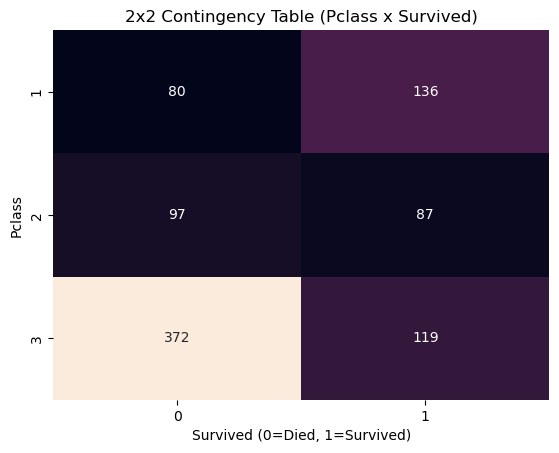

In [108]:
ct = pd.crosstab(data["Pclass"], data["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("2x2 Contingency Table (Pclass x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Pclass")

In [109]:
pd.crosstab(data1["Embarked"], data1["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


Text(50.722222222222214, 0.5, 'Embarked')

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

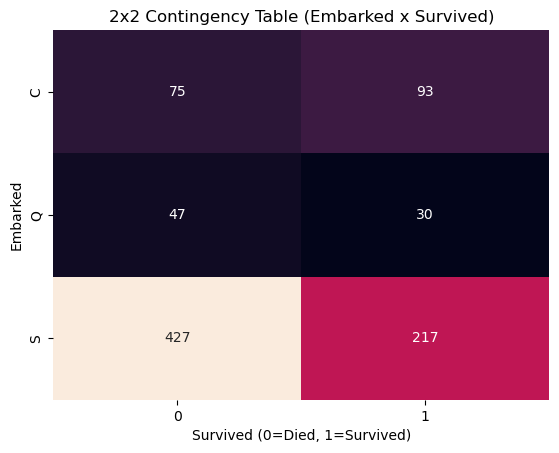

In [110]:
ct = pd.crosstab(data["Embarked"], data["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("2x2 Contingency Table (Embarked x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Embarked")

In [ ]:
data.head(n = 10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [117]:
data.tail(n=20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S


# 과제 1)

• Survived와 관련이 깊은 변수는 **Fare**이다. <br>

-> Pclass에 따라 Survived가 상이하다는 것은 어찌보면 자명한 사실일 수 있다. class가 낮을 수록 객실이 배 밑으로 향하기 때문이다. <br>
   
-> **Fare**를 확인해보았을 때, 운임의 가격이 높을 수록 상위 객실에 탑승하였을 확률이 크다. 추가적으로, class 별로 지낼 수 있는 층수가 다르다 <br>
      이를 **Fare**따라서 층수가 정해졌다고 가정하고 진행하겠다.

-> **Fare**에 따른 Survived 구하기


In [118]:
data1[['Pclass', 'Survived']]

,Pclass,Survived
0,3,0
1,1,1
2,3,1
3,1,1
4,3,0
...,...,...
886,2,0
887,1,1
888,3,0
889,1,1


In [106]:
data1[['Pclass', 'Fare']]

,Pclass,Fare
0,3,7.2500
1,1,71.2833
2,3,7.9250
3,1,53.1000
4,3,8.0500
...,...,...
886,2,13.0000
887,1,30.0000
888,3,23.4500
889,1,30.0000


### 1. Fare 결측치 확인 

### 2. Survived에 따른 Fare 평균 요금 구하기 <br>
-> Survived = 0일 때가 1일 때보다 Fare가 더 높다면 좋은 접근 x


In [ ]:
data1['Fare'].isnull().sum()

np.int64(0)

In [120]:
data.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

### 교차표 생성 및 카이제곱 검정 진행

In [148]:
ct_Fare = pd.crosstab(data['Survived'], data['Fare'])
ct_Fare

Fare,0.0000,4.0125,5.0000,6.2375,6.4375,6.4500,6.4958,6.7500,6.8583,6.9500,...,153.4625,164.8667,211.3375,211.5000,221.7792,227.5250,247.5208,262.3750,263.0000,512.3292
Survived,,,,,,,,,,,,,,,,,,,,,
0,14,1,1,1,1,1,2,2,1,1,...,1,0,0,1,1,1,1,0,2,0
1,1,0,0,0,0,0,0,0,0,0,...,2,2,3,0,0,3,1,2,2,3


In [ ]:
# Survived / Fare 독립성 검정
from scipy.stats import chi2_contingency   # 독립성 검정할 때 가져와야할 라이브러리!

q1 = data['Fare'].quantile(0.25)
q3 = data['Fare'].quantile(0.75)

data['Fare_group'] = pd.cut(
    data['Fare'],
    bins=[-float('inf'), q1, q3, float('inf')],
    labels=['low', 'middle', 'high']
)

ct_fare = pd.crosstab(data['Survived'], data['Fare_group'])

chi2, p, dof, expected = chi2_contingency(ct_fare)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 69.3700
p-value: 0.0000
Degrees of freedom: 2


• Fare은 숫자형 변수여서 너무 많은 값들이 있다. 25, 75 percentile로 구간을 나눠서 범주형 데이터로 나눈다. <br>

• 귀무가설(H0): Fare와 Survived는 독립이다. <br>

• P-value < 0.05이니 귀무가설을 기각한다. <br>

-> 즉 **운임**과 **생존율**은 통계적으로 유의미한 관계가 있다.

In [144]:
data['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
35.0000     1
28.5000     1
6.2375      1
14.0000     1
10.5167     1
Name: count, Length: 248, dtype: int64

## Fare 요금별 구간 나누기 <br>
low Fare = Low -< 25% percentile <br>

Middle Fare = 25% - 75% <br>

High Fare = 75% -< high <br>

• 평균값 기준이 아닌 percentile로 구간을 나눈 이유는, 이상치값인 512.xxxx가 존재하여 평균값이 데이터에서 기준값으로 타당하지 않기 때문

In [159]:
data1['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

• Fare 변수 범주형 데이터로 묶기 <br>

• 평균값이 약 32인데, max값이 약 512인 것으로 보았을 때, percentile 사용하는 것이 유리함. <br>

• 변수 범주 나누기
   
   **low -< 25% percentile**

   **25% percentile -< 50% percentile**

   **50% percentile -< high**

In [173]:
q1 = data1['Fare'].quantile(0.25)
q3 = data1['Fare'].quantile(0.75)

data1['Fare_group'] = pd.cut(
    data1['Fare'],
    bins=[-float('inf'), q1, q3, float('inf')],
    labels=['low', 'middle', 'high']
)

data1['Fare_group']

0         low
1        high
2      middle
3        high
4      middle
        ...  
886    middle
887    middle
888    middle
889    middle
890       low
Name: Fare_group, Length: 891, dtype: category
Categories (3, object): ['low' < 'middle' < 'high']

In [174]:
data1.groupby('Fare_group')['Survived'].mean()

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_44294/3159477509.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data1.groupby('Fare_group')['Survived'].mean()


Fare_group
low       0.197309
middle    0.378924
high      0.581081
Name: Survived, dtype: float64

### 결론)

• Fare는 Survived와 통계적으로 유의미한 관계가 있고, 이를 토대로 특정 범주로 나누어서 Survived에 관계를 확인함.

• Fare가 높을 수록 Pclass와 높을 거라는 추측과 동일하게 Fare가 높을 수록 높은 생존율을 보여줌.

• 즉, Fare가 높을 수록 생존율이 높다.